# F1 race prediction

# Block 1: load datasets

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# load all CSV files - automatically converting '\N' to NaN
results = pd.read_csv('data/results.csv', na_values=['\\N'])
races = pd.read_csv('data/races.csv', na_values=['\\N'])
drivers = pd.read_csv('data/drivers.csv', na_values=['\\N'])
constructors = pd.read_csv('data/constructors.csv', na_values=['\\N'])
d_standings = pd.read_csv('data/driver_standings.csv', na_values=['\\N'])
pit_stops = pd.read_csv('data/pit_stops.csv', na_values=['\\N'])
circuits = pd.read_csv('data/circuits.csv', na_values=['\\N'])

print("All data loaded successfully.")
# initialize a list to store results across all races for the final comparison
all_race_results = []

All data loaded successfully.


# Block 2: add relevant metadata to the results table and do some basic cleaning

In [2]:
# merge core race information
df = pd.merge(results, races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']], on='raceId')
df = pd.merge(df, drivers[['driverId', 'driverRef', 'dob', 'nationality']], on='driverId')
df = pd.merge(df, constructors[['constructorId', 'constructorRef', 'nationality']], on='constructorId', suffixes=('_driver', '_team'))
df = pd.merge(df, circuits[['circuitId', 'country']], on='circuitId')

# clean numeric columns
df['grid'] = df['grid'].fillna(20).astype(int) # if data missing we assume the 20th place
df['positionOrder'] = df['positionOrder'].astype(int) # finishing position
df['date'] = pd.to_datetime(df['date'])

# define the target: movement (delta) - design the prediction around the dynamic of the race and how each driver moves is the race
df['positions_changed'] = df['grid'] - df['positionOrder']

# sort data chronologically for rolling calculations, because later in the code we will use previous races
df = df.sort_values(['date', 'round'])

# Block 3: add some features (driver's age, experience, home country or not)


In [3]:
# driver age at the time of the race
df['dob'] = pd.to_datetime(df['dob'])
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

# cumulative experience
df['driver_experience'] = df.groupby('driverId').cumcount()

# home race advantage
# (if driver nationality matches circuit country - simplified mapping)
df['is_home_race_driver'] = (df['nationality_driver'] == df['country']).astype(int)
df['is_home_race_team'] = (df['nationality_team'] == df['country']).astype(int)

print("Profile features engineered.")

Profile features engineered.


# Block 4: bring in championship standings data and align it so that each driver’s points and wins before a race are used as predictive features.


In [4]:
# map race metadata to standings
standings_time = pd.merge(d_standings, races[['raceId', 'year', 'round']], on='raceId') # now each standing row knows which season and race round it belongs to

# move the standings forward by 1 race so we know the points before the race
standings_time['lookup_round'] = standings_time['round'] + 1

# rename the columns in the standings table before merging
# this avoids name collisions with the 'points' already in the variable 'df'
standings_to_merge = standings_time[['year', 'lookup_round', 'driverId', 'points', 'wins']].rename(
    columns={'points': 'points_before_race', 'wins': 'wins_before_race'}
)

# if you've run this cell before, remove the old columns so we don't get duplicates
cols_to_fix = ['points_before_race', 'wins_before_race', 'lookup_round']
df = df.drop(columns=[c for c in cols_to_fix if c in df.columns])

# now merge the pre-named columns
df = pd.merge(
    df,
    standings_to_merge,
    left_on=['year', 'round', 'driverId'],
    right_on=['year', 'lookup_round', 'driverId'],
    how='left'
)

# fill start-of-season zeros
df['points_before_race'] = df['points_before_race'].fillna(0)
df['wins_before_race'] = df['wins_before_race'].fillna(0)

print("Standings features merged successfull.")

Standings features merged successfull.


# Block 5: add some performance trend features

In [5]:
# driver's form in the last 3 races - again we shift this by one so the model doesn't see the result of the current race
df['driver_recent_form'] = df.groupby('driverId')['positionOrder'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
).fillna(15)

# team's form in the last 3 races - again we shift this by one so the model doesn't see the result of the current race
df['team_recent_form'] = df.groupby('constructorId')['positionOrder'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
).fillna(15)

# 3. performance at this specific circuit in previous years
df['driver_track_history'] = df.groupby(['driverId', 'circuitId'])['positionOrder'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
).fillna(15)

# Block 6: add some pit stop efficiency and reliability features

In [6]:
# the average of pit efficiency in the last 5 races
pit_stops['duration'] = pd.to_numeric(pit_stops['duration'], errors='coerce')
pit_avg = pd.merge(pit_stops, results[['raceId', 'driverId', 'constructorId']], on=['raceId', 'driverId'])
team_pit = pit_avg.groupby(['raceId', 'constructorId'])['duration'].mean().reset_index()

team_pit['constructor_pit_efficiency'] = team_pit.groupby('constructorId')['duration'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)

# add the pit efficiency in the dataset
df = pd.merge(df, team_pit[['raceId', 'constructorId', 'constructor_pit_efficiency']], on=['raceId', 'constructorId'], how='left')
df['constructor_pit_efficiency'] = df['constructor_pit_efficiency'].fillna(25)

# reliability (DNF rate in last 10 races)
# status 1 is "Finished" and 11, 12, 13, 14 are various codes for +1, +2, +3 laps
df['is_mechanical_dnf'] = df['statusId'].apply(lambda x: 1 if x not in [1, 11, 12, 13, 14] else 0)
df['team_reliability'] = df.groupby('constructorId')['is_mechanical_dnf'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
).fillna(0.1)

# Block 7: Monaco 2024 race prediction


In [7]:
# define features
features = [
    'grid', 'driver_age', 'driver_experience', 'points_before_race',
    'wins_before_race', 'driver_recent_form', 'team_recent_form',
    'driver_track_history', 'constructor_pit_efficiency', 'team_reliability',
    'is_home_race_driver', 'is_home_race_team'
]

# identify Monaco 2024
monaco_2024 = (df['year'] == 2024) & (df['name'].str.contains('Monaco'))

# use training data with races before the Monaco 2024 race
train_df = df[df['date'] < df[monaco_2024]['date'].min()].dropna(subset=features + ['positions_changed'])
test_df = df[monaco_2024].copy()



# define the used algorithms
models = {
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoost': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
}

# train and predict for the current race (targeting 'test_df')
for name, model in models.items():
    # use features as input data and positions_changed as output data
    model.fit(train_df[features], train_df['positions_changed'])

    # store raw predictions in the dataframe: thr predicted position gained/lost and the predicted rank
    pred_col = f'pred_delta_{name}'
    rank_col = f'rank_{name}'

    test_df[pred_col] = model.predict(test_df[features])
    test_df[rank_col] = (test_df['grid'] - test_df[pred_col]).rank(method='first').astype(int)

print(f"All 3 models trained for {test_df['name'].iloc[0]}!")

All 3 models trained for Monaco Grand Prix!


# Block 8: comparison plot for the 3 algorithms and the actual result


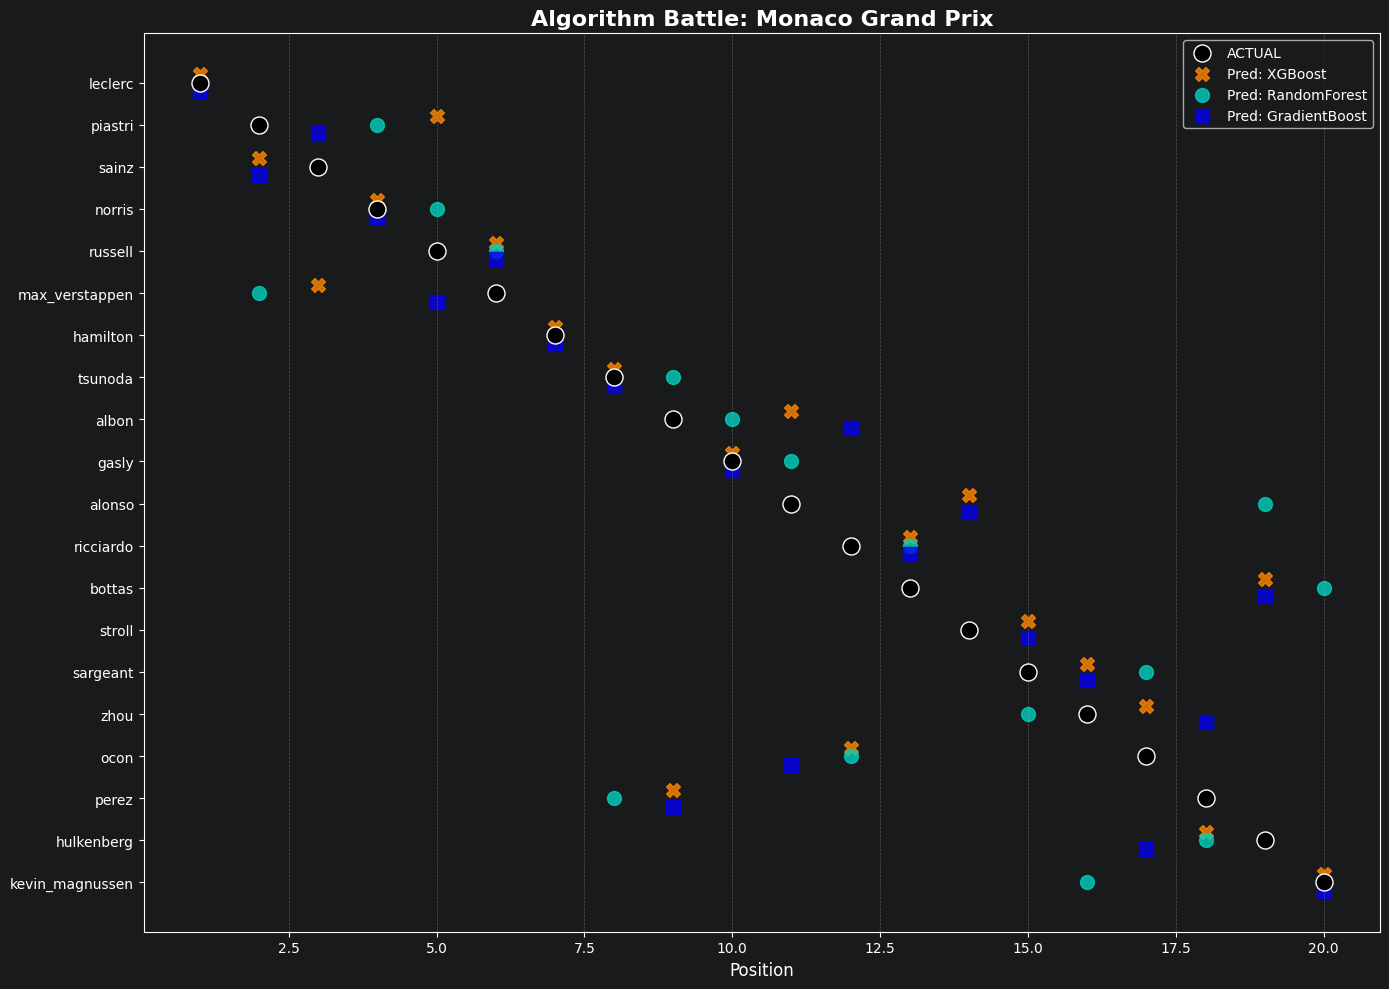

In [8]:

plt.figure(figsize=(14, 10))
plot_df = test_df.sort_values('positionOrder')

# Plot Actual Results
plt.scatter(plot_df['positionOrder'], plot_df['driverRef'], color='black', label='ACTUAL', s=150, edgecolors='white', zorder=5)

# Adjusted colors and markers
colors = {'XGBoost': '#FF8700', 'RandomForest': '#00D2BE', 'GradientBoost': '#0600EF'}
markers = {'XGBoost': 'X', 'RandomForest': 'o', 'GradientBoost': 's'}

# Add small Y-offsets so they don't perfectly overlap
y_offsets = {'XGBoost': -0.2, 'RandomForest': 0.0, 'GradientBoost': 0.2}

for name in models.keys():
    # Convert categorical Y-axis to numeric indices for adding offsets
    y_values = np.arange(len(plot_df)) + y_offsets[name]

    plt.scatter(plot_df[f'rank_{name}'], y_values,
                color=colors[name], marker=markers[name], label=f'Pred: {name}', s=100, alpha=0.8)

# Set Y-ticks back to driver names
plt.yticks(np.arange(len(plot_df)), plot_df['driverRef'])

plt.title(f"Algorithm Battle: {test_df['name'].iloc[0]}", fontsize=16, fontweight='bold')
plt.xlabel("Position", fontsize=12)
plt.gca().invert_yaxis()
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Block 9: evaluate each model's prediction accuracy


In [9]:

from sklearn.metrics import mean_absolute_error

race_name = test_df['name'].iloc[0]
print(f"\n--- MAE Comparison for {race_name} ---")

for name in models.keys():
    mae = mean_absolute_error(test_df['positionOrder'], test_df[f'rank_{name}'])
    print(f"{name} MAE: {mae:.2f} positions")

    # save to global results for the final summary
    all_race_results.append({
        'Race': race_name,
        'Model': name,
        'MAE': mae
    })


--- MAE Comparison for Monaco Grand Prix ---
XGBoost MAE: 1.90 positions
RandomForest MAE: 2.50 positions
GradientBoost MAE: 1.90 positions


# Block 10: feature importance comparison


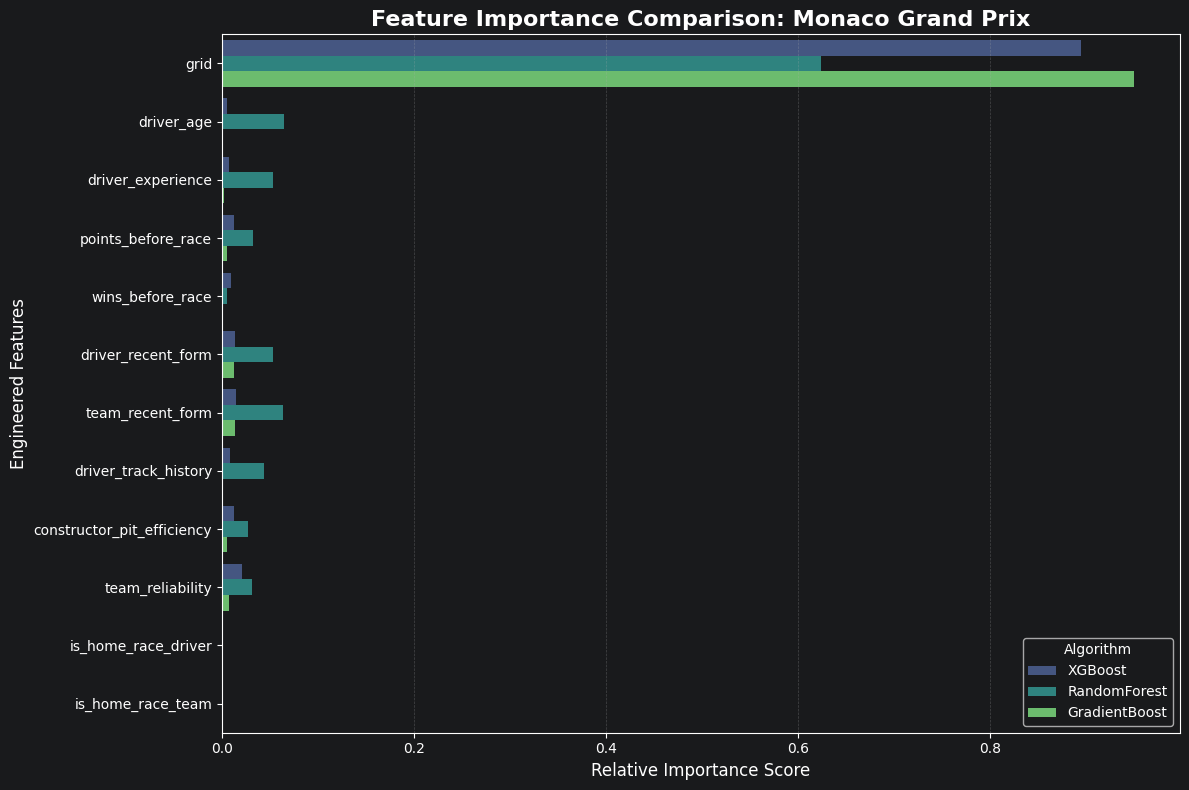

In [10]:
# collect importance data from all models
importance_list = []

for name, model in models.items():
    # create a small dataframe for each model's importance
    imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_,
        'Model': name
    })
    importance_list.append(imp_df)

# ombine into one "Master Importance" dataframe
comp_importance_df = pd.concat(importance_list)

# 3. Plotting the comparison
plt.figure(figsize=(12, 8))
sns.barplot(data=comp_importance_df, x='Importance', y='Feature', hue='Model', palette='viridis')

plt.title(f"Feature Importance Comparison: {test_df['name'].iloc[0]}", fontsize=16, fontweight='bold')
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Engineered Features", fontsize=12)
plt.legend(title='Algorithm', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Block 11: Dutch GP 2023 race prediction


In [11]:

# define features
features = [
    'grid', 'driver_age', 'driver_experience', 'points_before_race',
    'wins_before_race', 'driver_recent_form', 'team_recent_form',
    'driver_track_history', 'constructor_pit_efficiency', 'team_reliability',
    'is_home_race_driver', 'is_home_race_team'
]


dutch_2023 = (df['year'] == 2023) & (df['name'].str.contains('Dutch'))

# ensure we have data for this race
if dutch_2023.any():
    dutch_date = df[dutch_2023]['date'].min()

    # split: train on everything before Zandvoort 2023
    train_df = df[df['date'] < dutch_date].dropna(subset=features + ['positions_changed'])
    test_df = df[dutch_2023].copy()

#learning_rate = used to control how much each tree contributes to the final prediction
    models = {
        'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
        'GradientBoost': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
    }

    # train and predict for the current race (Targeting 'test_df')
    for name, model in models.items():
        model.fit(train_df[features], train_df['positions_changed'])

        # Store raw predictions in the dataframe
        pred_col = f'pred_delta_{name}'
        rank_col = f'rank_{name}'

        test_df[pred_col] = model.predict(test_df[features])
        test_df[rank_col] = (test_df['grid'] - test_df[pred_col]).rank(method='first').astype(int)

    print(f"All 3 models trained for {test_df['name'].iloc[0]}!")
else:
    print("Error: Dutch 2023 data not found.")

All 3 models trained for Dutch Grand Prix!


# Block 12: comparison plot for the 3 algorithms and the actual result


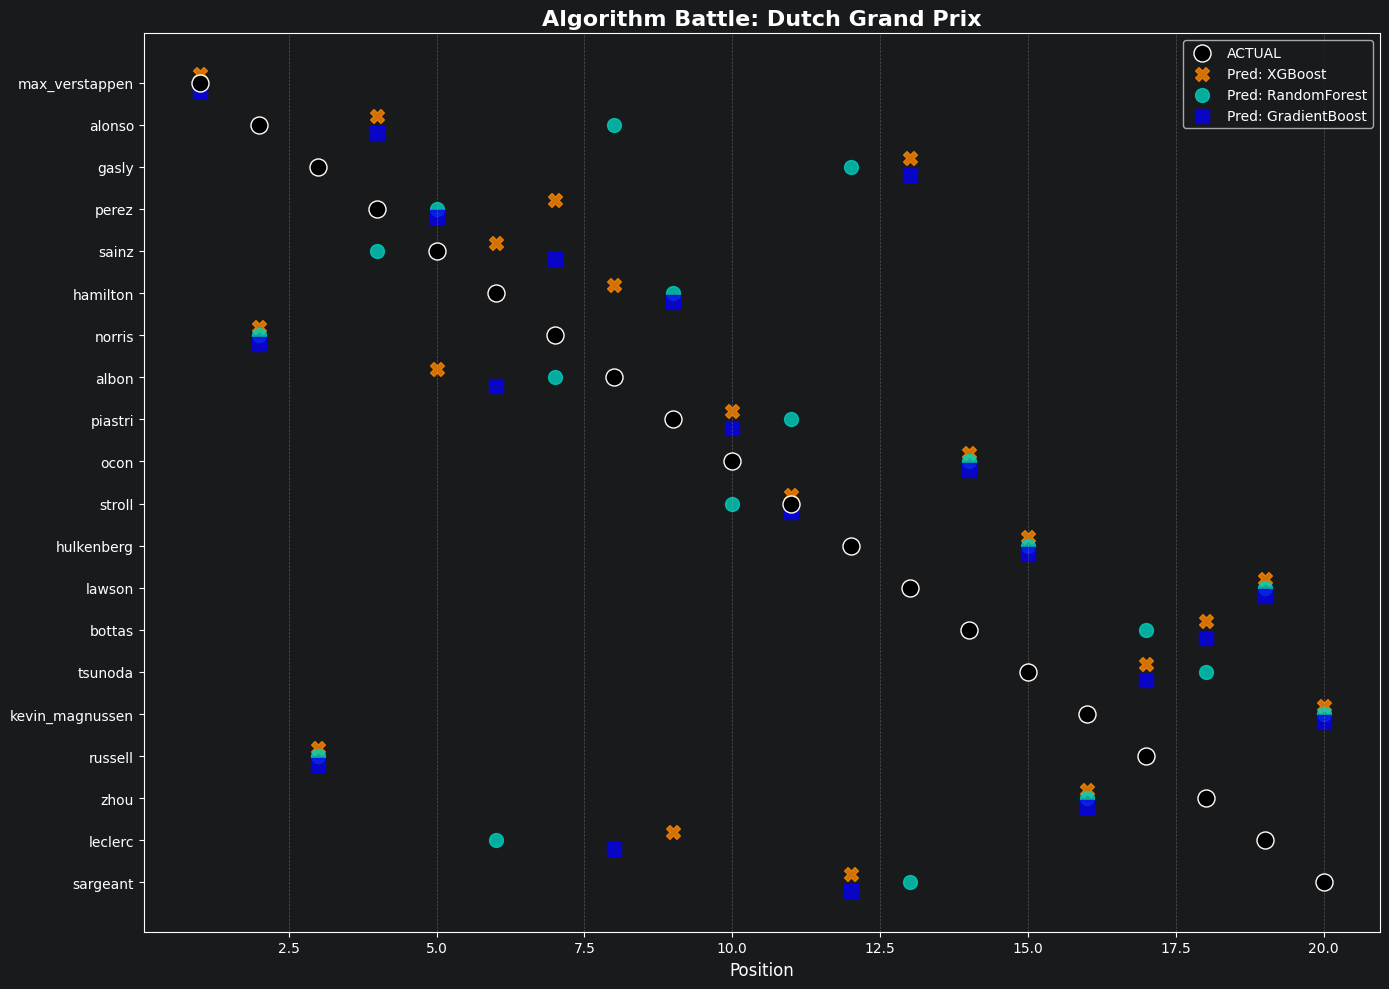

In [12]:

plt.figure(figsize=(14, 10))
plot_df = test_df.sort_values('positionOrder')

# Plot Actual Results
plt.scatter(plot_df['positionOrder'], plot_df['driverRef'], color='black', label='ACTUAL', s=150, edgecolors='white', zorder=5)

# Adjusted colors and markers
colors = {'XGBoost': '#FF8700', 'RandomForest': '#00D2BE', 'GradientBoost': '#0600EF'}
markers = {'XGBoost': 'X', 'RandomForest': 'o', 'GradientBoost': 's'}

# Add small Y-offsets so they don't perfectly overlap
y_offsets = {'XGBoost': -0.2, 'RandomForest': 0.0, 'GradientBoost': 0.2}

for name in models.keys():
    # Convert categorical Y-axis to numeric indices for adding offsets
    y_values = np.arange(len(plot_df)) + y_offsets[name]

    plt.scatter(plot_df[f'rank_{name}'], y_values,
                color=colors[name], marker=markers[name], label=f'Pred: {name}', s=100, alpha=0.8)

# Set Y-ticks back to driver names
plt.yticks(np.arange(len(plot_df)), plot_df['driverRef'])

plt.title(f"Algorithm Battle: {test_df['name'].iloc[0]}", fontsize=16, fontweight='bold')
plt.xlabel("Position", fontsize=12)
plt.gca().invert_yaxis()
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Block 13: evaluate each model's prediction accuracy


In [13]:

from sklearn.metrics import mean_absolute_error

race_name = test_df['name'].iloc[0]
print(f"\n--- MAE Comparison for {race_name} ---")

for name in models.keys():
    mae = mean_absolute_error(test_df['positionOrder'], test_df[f'rank_{name}'])
    print(f"{name} MAE: {mae:.2f} positions")

    # save to global results for the final summary
    all_race_results.append({
        'Race': race_name,
        'Model': name,
        'MAE': mae
    })


--- MAE Comparison for Dutch Grand Prix ---
XGBoost MAE: 4.20 positions
RandomForest MAE: 4.40 positions
GradientBoost MAE: 4.20 positions


# Block 14: feature importance comparison


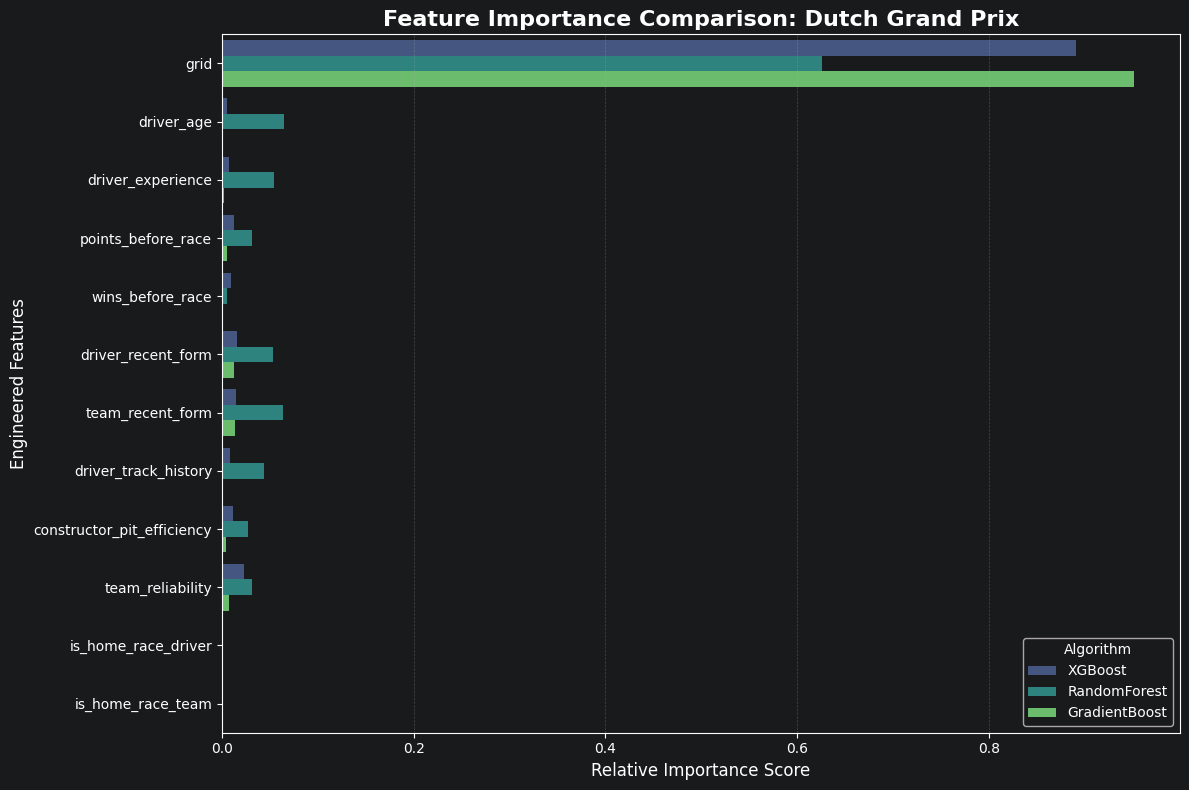

In [14]:


# collect importance data from all models
importance_list = []

for name, model in models.items():
    # Create a small dataframe for each model's importance
    imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_,
        'Model': name
    })
    importance_list.append(imp_df)

# combine into one "Master Importance" dataframe
comp_importance_df = pd.concat(importance_list)

# 3. Plotting the comparison
plt.figure(figsize=(12, 8))
sns.barplot(data=comp_importance_df, x='Importance', y='Feature', hue='Model', palette='viridis')

plt.title(f"Feature Importance Comparison: {test_df['name'].iloc[0]}", fontsize=16, fontweight='bold')
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Engineered Features", fontsize=12)
plt.legend(title='Algorithm', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Block 15: Brazilian GP 2023 race prediction


In [15]:


# Identify Brazil 2023 (Interlagos)
brazil_2023 = (df['year'] == 2023) & (df['name'].str.contains('São Paulo Grand Prix'))

if brazil_2023.any():
    brazil_date = df[brazil_2023]['date'].min()

    # Split: Train on everything before the Brazil 2023 weekend
    train_df = df[df['date'] < brazil_date].dropna(subset=features + ['positions_changed'])
    test_df = df[brazil_2023].copy()

    models = {
        'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
        'GradientBoost': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
    }

    # train and predict for the current race (Targeting 'test_df')
    for name, model in models.items():
        model.fit(train_df[features], train_df['positions_changed'])

        # Store raw predictions in the dataframe
        pred_col = f'pred_delta_{name}'
        rank_col = f'rank_{name}'

        test_df[pred_col] = model.predict(test_df[features])
        test_df[rank_col] = (test_df['grid'] - test_df[pred_col]).rank(method='first').astype(int)

    print(f"All 3 models trained for {test_df['name'].iloc[0]}!")
else:
    print("Error: Brazil 2023 data not found. Check if the name in races.csv is 'São Paulo Grand Prix'.")

All 3 models trained for São Paulo Grand Prix!


# Block 16: comparison plot for the 3 algorithms and the actual result


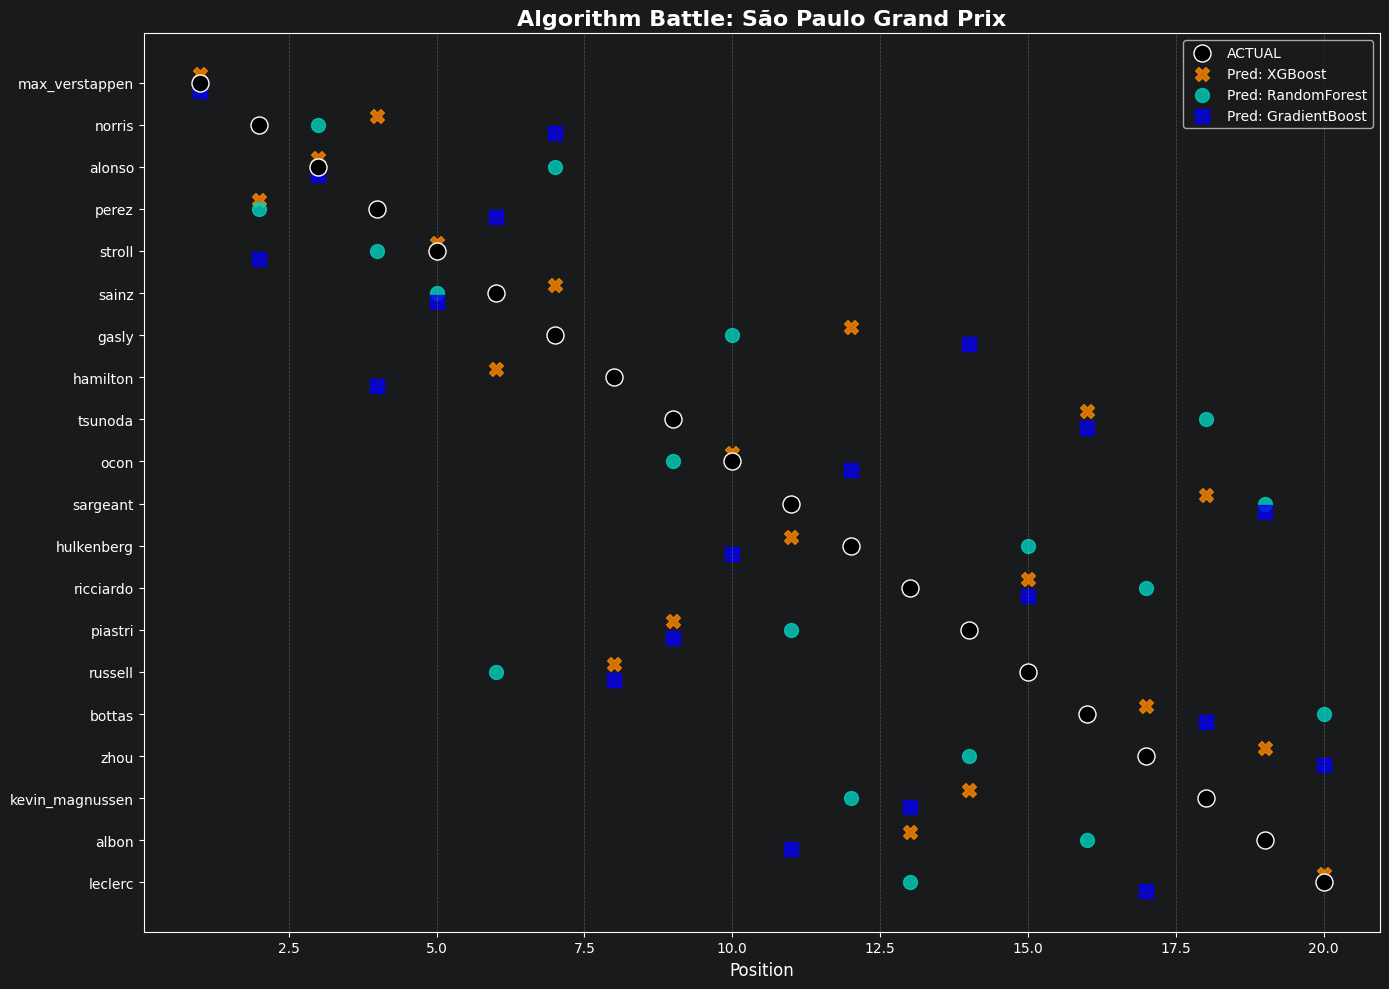

In [16]:

plt.figure(figsize=(14, 10))
plot_df = test_df.sort_values('positionOrder')

# Plot Actual Results
plt.scatter(plot_df['positionOrder'], plot_df['driverRef'], color='black', label='ACTUAL', s=150, edgecolors='white', zorder=5)

# Adjusted colors and markers
colors = {'XGBoost': '#FF8700', 'RandomForest': '#00D2BE', 'GradientBoost': '#0600EF'}
markers = {'XGBoost': 'X', 'RandomForest': 'o', 'GradientBoost': 's'}

# Add small Y-offsets so they don't perfectly overlap
y_offsets = {'XGBoost': -0.2, 'RandomForest': 0.0, 'GradientBoost': 0.2}

for name in models.keys():
    # Convert categorical Y-axis to numeric indices for adding offsets
    y_values = np.arange(len(plot_df)) + y_offsets[name]

    plt.scatter(plot_df[f'rank_{name}'], y_values,
                color=colors[name], marker=markers[name], label=f'Pred: {name}', s=100, alpha=0.8)

# Set Y-ticks back to driver names
plt.yticks(np.arange(len(plot_df)), plot_df['driverRef'])

plt.title(f"Algorithm Battle: {test_df['name'].iloc[0]}", fontsize=16, fontweight='bold')
plt.xlabel("Position", fontsize=12)
plt.gca().invert_yaxis()
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Block 17: evaluate each model's prediction accuracy


In [17]:

from sklearn.metrics import mean_absolute_error

race_name = test_df['name'].iloc[0]
print(f"\n--- MAE Comparison for {race_name} ---")

for name in models.keys():
    mae = mean_absolute_error(test_df['positionOrder'], test_df[f'rank_{name}'])
    print(f"{name} MAE: {mae:.2f} positions")

    # Save to global results for the final summary
    all_race_results.append({
        'Race': race_name,
        'Model': name,
        'MAE': mae
    })


--- MAE Comparison for São Paulo Grand Prix ---
XGBoost MAE: 2.70 positions
RandomForest MAE: 3.60 positions
GradientBoost MAE: 3.80 positions


# Block 18: feature importance comparison


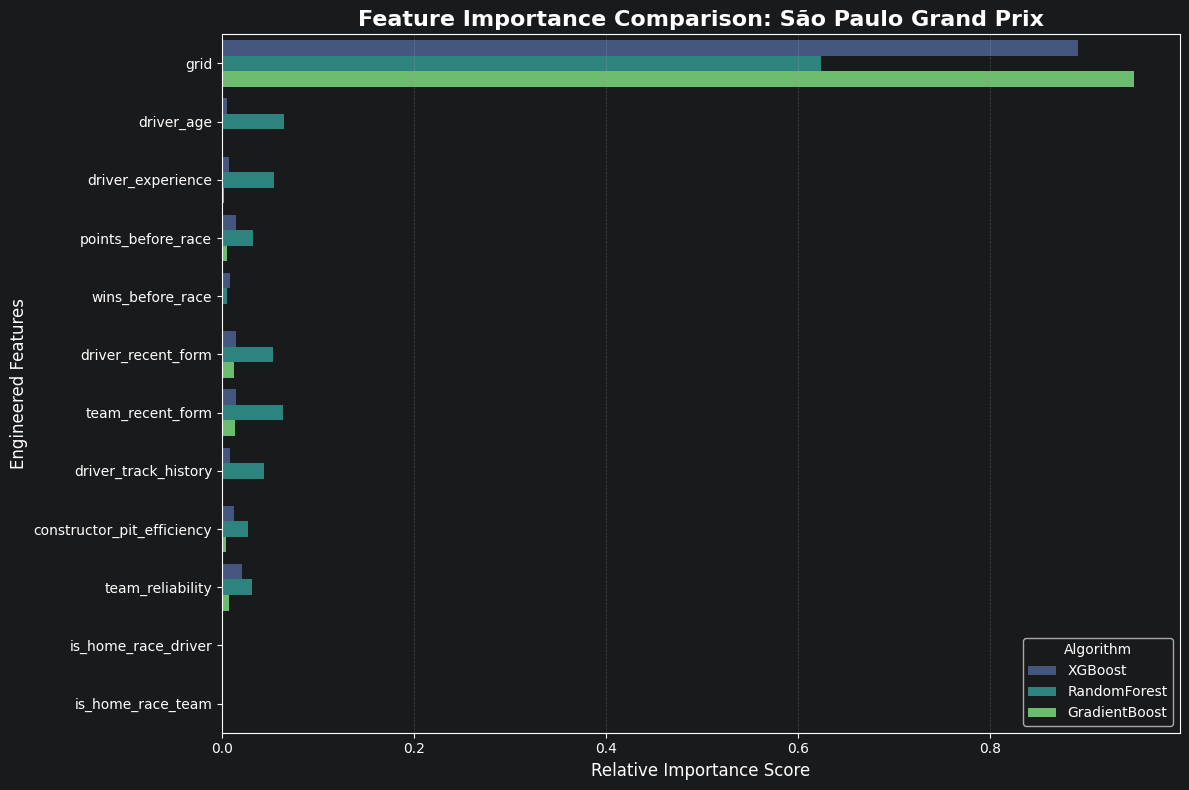

In [18]:


# collect importance data from all models
importance_list = []

for name, model in models.items():
    # create a small dataframe for each model's importance
    imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_,
        'Model': name
    })
    importance_list.append(imp_df)

# combine into one "Master Importance" dataframe
comp_importance_df = pd.concat(importance_list)

# plotting the comparison
plt.figure(figsize=(12, 8))
sns.barplot(data=comp_importance_df, x='Importance', y='Feature', hue='Model', palette='viridis')

plt.title(f"Feature Importance Comparison: {test_df['name'].iloc[0]}", fontsize=16, fontweight='bold')
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Engineered Features", fontsize=12)
plt.legend(title='Algorithm', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Block 19: algorithm comparison summary


C:\Users\Ioana\AppData\Local\Temp\ipykernel_35656\4078320766.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_summary, x='Model', y='MAE', palette='magma')


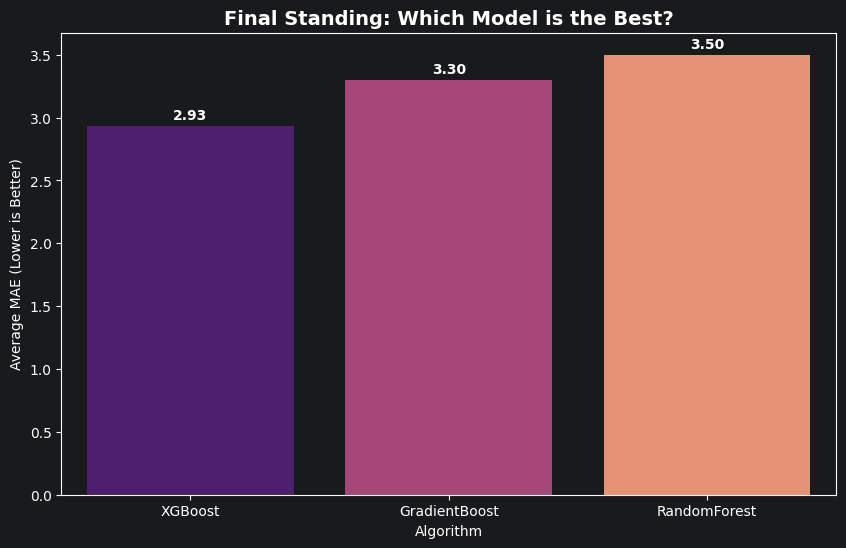


--- Final Tournament Standings ---
           Model       MAE
0        XGBoost  2.933333
1  GradientBoost  3.300000
2   RandomForest  3.500000


In [19]:

global_df = pd.DataFrame(all_race_results)

# Aggregate results
final_summary = global_df.groupby('Model')['MAE'].mean().sort_values().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='Model', y='MAE', palette='magma')

plt.title("Final Standing: Which Model is the Best?", fontsize=14, fontweight='bold')
plt.ylabel("Average MAE (Lower is Better)")
plt.xlabel("Algorithm")

for i, val in enumerate(final_summary['MAE']):
    plt.text(i, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold')

plt.show()

print("\n--- Final Tournament Standings ---")
print(final_summary)